In [23]:
#Biblioteke
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm, poisson, cauchy, iqr, uniform
from scipy.stats import kstwo, kstest, ks_2samp
from scipy.stats import mannwhitneyu, ranksums, wilcoxon, anderson, shapiro, ttest_ind, ttest_1samp, f
from urllib.request import urlopen
import matplotlib
from matplotlib import pyplot as plt
from scipy.stats import mannwhitneyu, ks_2samp
matplotlib.rcParams.update({"text.usetex": False, "font.size" : 10, "font.family": "monospace"})

In [25]:
#Iz pdfa za ucitavanje podataka
ks_uzorci = np.genfromtxt('gr.dat', skip_header=2, skip_footer=2)
mJy, G, R = ks_uzorci.T

Podaci su dati kao histogram, tj. za svaku vrednost gustine fluksa S dato je koliko puta se pojavljuje u uzorcima G i R.
Zato moramo rekonstruisati sirove uzorke pomoću np.repeat, jer statistički testovi rade nad pojedinačnim merenjima, a ne direktno nad histogramom.

In [62]:
#Rekonstrukcija sirovih uzoraka iz histograma

sirovi_G = np.repeat(mJy, np.rint(G).astype(int))
sirovi_R = np.repeat(mJy, np.rint(R).astype(int))

print("Broj merenja u G uzorku:", len(sirovi_G))
print("Broj merenja u R uzorku:", len(sirovi_R))

print("Srednja vrednost G:", np.mean(sirovi_G))
print("Srednja vrednost R:", np.mean(sirovi_R))

print("Medijana G:", np.median(sirovi_G))
print("Medijana R:", np.median(sirovi_R))

Broj merenja u G uzorku: 386
Broj merenja u R uzorku: 290
Srednja vrednost G: 0.4378238341968912
Srednja vrednost R: 0.32413793103448274
Medijana G: 0.0
Medijana R: 0.5


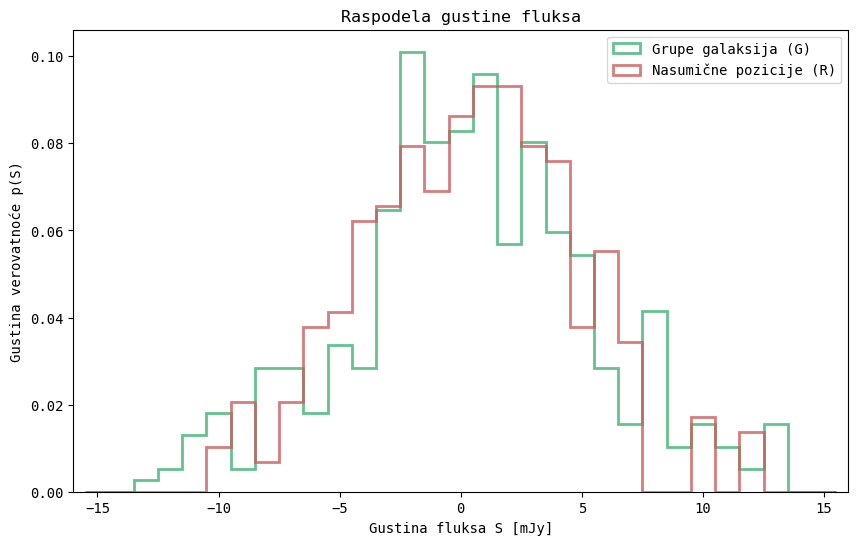

In [64]:
#Plot
plt.figure(figsize=(10, 6))

bins = np.arange(-15.5, 16.5, 1.0)

plt.hist(sirovi_G,bins=bins,histtype='step',lw=2,color='mediumseagreen',alpha=0.8,density=True,label='Grupe galaksija (G)')
plt.hist(sirovi_R,bins=bins,histtype='step',lw=2,color='indianred',alpha=0.8,density=True,label='Nasumične pozicije (R)')
plt.xlabel('Gustina fluksa S [mJy]')
plt.ylabel('Gustina verovatnoće p(S)')
plt.title('Raspodela gustine fluksa')
plt.xlim(-16, 16)
plt.legend()
plt.show()

In [66]:
# Kolmogorov-Smirnov test

ks_rezultat = ks_2samp(sirovi_G, sirovi_R, alternative='less')
print("KS test:")
print(ks_rezultat)

KS test:
KstestResult(statistic=0.06741111309630159, pvalue=0.20990505201364298, statistic_location=7.0, statistic_sign=-1)


In [68]:
# U-test

u_rezultat = mannwhitneyu(sirovi_G, sirovi_R, alternative='greater')
print("Mann-Whitney U-test:")
print(u_rezultat)

Mann-Whitney U-test:
MannwhitneyuResult(statistic=56613.5, pvalue=0.3988043118334691)


Na osnovu oba testa zaključujemo da ne možemo odbaciti nultu hipotezu.
Iako je srednja vrednost za grupe galaksija malo veća, u odnosu na nasumične pozicije.
Ta razlika nije statistički značajna prema primenjenim testovima.
Zato zaključujemo da na osnovu ovih podataka nema dovoljno statističkih dokaza da postoji eksces gustine fluksa na pozicijama grupa galaksija.

In [73]:
np.random.seed(0)

n = 10
epsilon = 0.0
mu = 0.0

#Prvi uzorak
sample1 = norm.rvs(0, 1, n)

#Drugi uzorak

n2 = np.random.binomial(n, epsilon)
n1 = n - n2

komponenta1 = norm.rvs(mu, 1, n1)
komponenta2 = norm.rvs(0, 3, n2)

sample2 = np.concatenate((komponenta1, komponenta2))
np.random.shuffle(sample2)

#t-test za jednu realizaciju
print(ttest_ind(sample1, sample2, equal_var=False))

TtestResult(statistic=0.4779578315792188, pvalue=0.6384390126896287, df=17.981975070987932)


Dobijen je rezultat t-testa:
t = 0.4779578315792188
p = 0.6384390126896287

Pošto je p-vrednost veća od nivoa značajnosti alpha = 0.05, odnosno
p = 0.638 > 0.05,
ne odbacujemo nultu hipotezu. To znači da za ovu jednu realizaciju nema statistički značajne razlike između srednjih vrednosti dva uzorka.
Ovaj rezultat je očekivan, jer su za epsilon = 0 i mu = 0 oba uzorka generisana iz raspodela centriranih oko nule.


In [76]:
np.random.seed(0)

epsilons = np.linspace(0, 0.5, 20)

def stopa_odbacivanja(epsilons, mu, n=10, N=1000, alpha=0.05):
    udeo_odbacivanja = []

    for eps in epsilons:
        broj_odbacivanja = 0
        for i in range(N):
            sample1 = norm.rvs(0, 1, n)
            n2 = np.random.binomial(n, eps)
            n1 = n - n2
            komp1 = norm.rvs(mu, 1, n1)
            komp2 = norm.rvs(0, 3, n2)
            sample2 = np.concatenate((komp1, komp2))
            stat, p = ttest_ind(sample1, sample2, equal_var=False)
            if p < alpha:
                broj_odbacivanja += 1
        udeo_odbacivanja.append(broj_odbacivanja / N)

    return np.array(udeo_odbacivanja)

In [78]:
# Racunamo stopu odbacivanja za dva slucaja
udeo_odbacivanja1 = stopa_odbacivanja(epsilons, mu=0, n=10, N=1000, alpha=0.05)
udeo_odbacivanja2 = stopa_odbacivanja(epsilons, mu=0.5, n=10, N=1000, alpha=0.05)

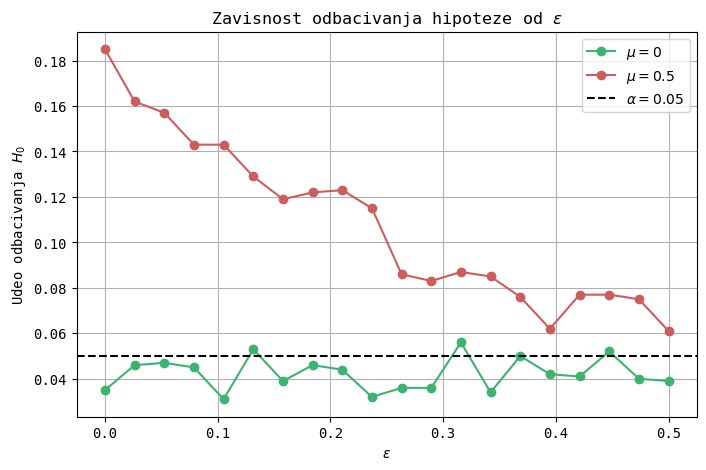

In [79]:
# Plotovanje

plt.figure(figsize=(8, 5))
plt.plot(epsilons, udeo_odbacivanja1, marker='o', color='mediumseagreen', label=r'$\mu = 0$')
plt.plot(epsilons, udeo_odbacivanja2, marker='o', color='indianred', label=r'$\mu = 0.5$')
plt.axhline(0.05, linestyle='--', color='black', label=r'$\alpha = 0.05$')
plt.xlabel(r'$\varepsilon$')
plt.ylabel(r'Udeo odbacivanja $H_0$')
plt.title(r'Zavisnost odbacivanja hipoteze od $\varepsilon$')
plt.legend()
plt.grid()
plt.show()

Na grafiku je prikazan udeo slučajeva u kojima je odbačena nulta hipoteza H0: mu1 = mu2 u zavisnosti od parametra epsilon.
Za svaku vrednost epsilon postupak generisanja dva uzorka i primene t-testa ponovljen je 1000 puta. Zatim je izračunat udeo slučajeva u kojima je p-vrednost bila manja od 0.05, tj. udeo slučajeva u kojima je nulta hipoteza odbačena.
Horizontalna isprekidana linija označava nivo značajnosti alpha = 0.05. To znači da, ako je nulta hipoteza tačna, očekujemo da se ona pogrešno odbaci u približno 5% slučajeva.

Za slučaj mu = 0, nulta hipoteza je tačna, jer oba uzorka imaju istu srednju vrednost. Zbog toga se udeo odbacivanja H0 kreće približno oko očekivanih 5%.
Za slučaj mu = 0.5, postoji stvarna razlika srednjih vrednosti kada je epsilon malo, pa je udeo odbacivanja veći od 5%. Međutim, kako epsilon raste, srednja vrednost mešavine se približava nuli i razlika između uzoraka postaje manja. Zbog toga opada udeo odbacivanja nulte hipoteze.